In [1]:
import os

print("Current working folder:")
print(os.getcwd())

print("\nFiles and folders here:")
print(os.listdir())

Current working folder:
c:\Users\purna\Downloads\Financial_Fraud_Detection\Financial_Fraud_Detection

Files and folders here:
['.venv', 'data', 'financial_fraud_cleaned.csv', 'Member1_Data_Preprocessing_EDA.ipynb', 'Member2_Feature_engineering_ML.ipynb']


In [ ]:
import pandas as pd
import numpy as np


df = pd.read_csv("financial_fraud_cleaned.csv")


print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (50000, 18)

Column Names:
['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Date', 'Account_Balance', 'Device_Type', 'Location', 'Merchant_Category', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Card_Type', 'Card_Age', 'Fraud_Label', 'Month', 'Year', 'Day', 'Day_of_Week_Number']


In [9]:
print(df[["Transaction_Amount", "Account_Balance"]].describe())


       Transaction_Amount  Account_Balance
count        50000.000000     50000.000000
mean            99.411012     50294.065981
std             98.687292     28760.458557
min              0.000000       500.480000
25%             28.677500     25355.995000
50%             69.660000     50384.430000
75%            138.852500     75115.135000
max           1174.140000     99998.310000


In [10]:
from sklearn.model_selection import train_test_split

# Remove columns that should not be used as ML features
drop_columns = [
    "Transaction_ID",
    "User_ID",
    "Date",
    "Year"
]

# Features (inputs)
X = df.drop(columns=drop_columns + ["Fraud_Label"])

# Target (what we want to predict)
y = df["Fraud_Label"]

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training data: (40000, 13)
Testing data: (10000, 13)

Training target distribution:
Fraud_Label
0    67.865
1    32.135
Name: proportion, dtype: float64

Testing target distribution:
Fraud_Label
0    67.87
1    32.13
Name: proportion, dtype: float64


Preprocessing pipeline created successfully.


In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Create improved preprocessing transformer
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", StandardScaler(), numerical_features)
    ]
)

print("Scaled preprocessing pipeline created successfully.")

Scaled preprocessing pipeline created successfully.


In [16]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

print("Updated baseline model created successfully.")

Updated baseline model created successfully.


In [17]:
baseline_model.fit(X_train, y_train)

print("Updated baseline model training completed.")

Updated baseline model training completed.


In [18]:
# Make predictions on the unseen test data
y_pred = baseline_model.predict(X_test)

print("Predictions completed.")
print("First 10 predictions:")
print(y_pred[:10])

Predictions completed.
First 10 predictions:
[0 0 0 0 0 0 0 0 0 0]


In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Get fraud probabilities for ROC-AUC
y_prob = baseline_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

print("Baseline Model Performance")
print("=" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Baseline Model Performance
Accuracy : 0.6787
Precision: 0.0000
Recall   : 0.0000
F1-Score : 0.0000
ROC-AUC  : 0.4910

Classification Report:
              precision    recall  f1-score   support

           0       0.68      1.00      0.81      6787
           1       0.00      0.00      0.00      3213

    accuracy                           0.68     10000
   macro avg       0.34      0.50      0.40     10000
weighted avg       0.46      0.68      0.55     10000


Confusion Matrix:
[[6787    0]
 [3213    0]]


c:\Users\purna\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\purna\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\purna\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [21]:
try:
    import xgboost
    print("XGBoost version:", xgboost.__version__)
except ImportError:
    print("XGBoost is not installed.")

XGBoost is not installed.


In [22]:
%pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 730.2 kB/s eta 0:01:07
    --------------------------------------- 0.8/48.9 MB 819.2 kB/s eta 0:00:59
    --------------------------------------- 1.0/48.9 MB 868.0 kB/s eta 0:00:56
   - -------------------------------------- 1.3/48.9 MB 919.8 kB/s eta 0:00:52
   - -------------------------------------- 1.6/48.9 MB 953.2 kB/s eta 0:00:50
   - -------------------------------------- 1.8/48.9 MB 996.7 kB/s eta 0:00:48
   - -------------------------------------- 2.1/48.9 MB 1.0 MB/s eta 0:00:46
   - ------------------------


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import xgboost

print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.4.1


In [24]:
from xgboost import XGBClassifier

# Create XGBoost model
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss"
        ))
    ]
)

print("XGBoost model pipeline created successfully.")

XGBoost model pipeline created successfully.


In [25]:
# Train the XGBoost model
xgb_model.fit(X_train, y_train)

print("XGBoost model training completed.")

XGBoost model training completed.


In [27]:
# Make predictions using XGBoost
xgb_pred = xgb_model.predict(X_test)

# Get fraud probabilities
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost predictions completed.")
print("First 10 predictions:")
print(xgb_pred[:10])

XGBoost predictions completed.
First 10 predictions:
[0 0 0 0 0 0 0 0 0 0]


In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Calculate XGBoost metrics
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred, zero_division=0)
xgb_recall = recall_score(y_test, xgb_pred, zero_division=0)
xgb_f1 = f1_score(y_test, xgb_pred, zero_division=0)
xgb_roc_auc = roc_auc_score(y_test, xgb_prob)

print("XGBoost Model Performance")
print("=" * 40)
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

XGBoost Model Performance
Accuracy : 0.6725
Precision: 0.3239
Recall   : 0.0177
F1-Score : 0.0336
ROC-AUC  : 0.5018

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.98      0.80      6787
           1       0.32      0.02      0.03      3213

    accuracy                           0.67     10000
   macro avg       0.50      0.50      0.42     10000
weighted avg       0.56      0.67      0.56     10000


Confusion Matrix:
[[6668  119]
 [3156   57]]


In [29]:
from sklearn.metrics import roc_auc_score

# XGBoost probability predictions on training data
xgb_train_prob = xgb_model.predict_proba(X_train)[:, 1]

# Calculate training ROC-AUC
xgb_train_auc = roc_auc_score(y_train, xgb_train_prob)

print("XGBoost Training ROC-AUC:", round(xgb_train_auc, 4))
print("XGBoost Testing ROC-AUC :", round(xgb_roc_auc, 4))

XGBoost Training ROC-AUC: 0.8687
XGBoost Testing ROC-AUC : 0.5018


In [30]:
from sklearn.feature_selection import mutual_info_classif

# Transform the training data using our preprocessing pipeline
X_train_processed = preprocessor.fit_transform(X_train)

# Calculate mutual information
mi_scores = mutual_info_classif(
    X_train_processed,
    y_train,
    random_state=42
)

print("Number of processed features:", X_train_processed.shape[1])
print("Mutual Information calculated successfully.")

Number of processed features: 29
Mutual Information calculated successfully.


In [31]:
# Get feature names after one-hot encoding
feature_names = preprocessor.get_feature_names_out()

mi_results = pd.DataFrame({
    "Feature": feature_names,
    "Mutual_Information": mi_scores
})

mi_results = mi_results.sort_values(
    by="Mutual_Information",
    ascending=False
)

print(mi_results.head(20).to_string(index=False))

                                     Feature  Mutual_Information
           categorical__Card_Type_Mastercard            0.006356
       categorical__Merchant_Category_Travel            0.005145
           categorical__Transaction_Type_POS            0.003422
                 categorical__Location_Tokyo            0.003355
             categorical__Card_Type_Discover            0.002820
                categorical__Location_Mumbai            0.002797
             categorical__Device_Type_Tablet            0.002706
                            numerical__Month            0.002429
               numerical__Day_of_Week_Number            0.001989
             categorical__Device_Type_Mobile            0.001899
                 categorical__Card_Type_Visa            0.001422
                              numerical__Day            0.001154
  categorical__Merchant_Category_Restaurants            0.000799
  categorical__Merchant_Category_Electronics            0.000745
                categoric

In [32]:
# Check the date range
df["Date"] = pd.to_datetime(df["Date"])

print("Earliest date:", df["Date"].min())
print("Latest date:", df["Date"].max())

# Check whether the dataset is already sorted by date
print("\nIs dataset chronologically sorted?")
print(df["Date"].is_monotonic_increasing)

Earliest date: 2023-01-01 00:00:00
Latest date: 2023-12-31 00:00:00

Is dataset chronologically sorted?
False


In [33]:
# Check how many transactions users have
user_transaction_counts = df["User_ID"].value_counts()

print("Total unique users:", user_transaction_counts.size)
print("\nUser transaction count statistics:")
print(user_transaction_counts.describe())

print("\nUsers with more than one transaction:",
      (user_transaction_counts > 1).sum())

Total unique users: 8963

User transaction count statistics:
count    8963.000000
mean        5.578489
std         2.331861
min         1.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        16.000000
Name: count, dtype: float64

Users with more than one transaction: 8768


In [34]:
# Check fraud history across users
user_fraud_summary = df.groupby("User_ID")["Fraud_Label"].agg(
    Total_Transactions="count",
    Fraud_Transactions="sum"
)

print("Users with at least one fraud transaction:",
      (user_fraud_summary["Fraud_Transactions"] > 0).sum())

print("Users with multiple fraud transactions:",
      (user_fraud_summary["Fraud_Transactions"] > 1).sum())


Users with at least one fraud transaction: 7482
Users with multiple fraud transactions: 4826


In [35]:
# Create a separate dataframe for time-aware feature engineering
behavior_df = df.copy()

# Convert Date to datetime
behavior_df["Date"] = pd.to_datetime(behavior_df["Date"])

# Sort by User_ID and Date
behavior_df = behavior_df.sort_values(
    ["User_ID", "Date"]
).reset_index(drop=True)

print("Behavioral feature dataset prepared.")
print("Shape:", behavior_df.shape)

Behavioral feature dataset prepared.
Shape: (50000, 18)


In [36]:
# Feature 1: Number of previous transactions by the user

behavior_df["Previous_User_Transactions"] = (
    behavior_df.groupby("User_ID").cumcount()
)

print("Previous_User_Transactions created successfully.")

print(
    behavior_df[
        ["User_ID", "Date", "Previous_User_Transactions"]
    ].head(15)
)

Previous_User_Transactions created successfully.
      User_ID       Date  Previous_User_Transactions
0   USER_1000 2023-02-21                           0
1   USER_1000 2023-04-26                           1
2   USER_1000 2023-09-01                           2
3   USER_1000 2023-10-29                           3
4   USER_1000 2023-12-03                           4
5   USER_1001 2023-01-25                           0
6   USER_1001 2023-02-20                           1
7   USER_1001 2023-03-18                           2
8   USER_1001 2023-09-16                           3
9   USER_1001 2023-09-17                           4
10  USER_1001 2023-09-23                           5
11  USER_1001 2023-12-09                           6
12  USER_1002 2023-02-23                           0
13  USER_1002 2023-04-13                           1
14  USER_1002 2023-08-06                           2


In [37]:
# Feature 2: User's average transaction amount before the current transaction

behavior_df["Previous_Avg_Amount"] = (
    behavior_df.groupby("User_ID")["Transaction_Amount"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

print("Previous_Avg_Amount created successfully.")

print(
    behavior_df[
        ["User_ID", "Date", "Transaction_Amount", "Previous_Avg_Amount"]
    ].head(15)
)

Previous_Avg_Amount created successfully.
      User_ID       Date  Transaction_Amount  Previous_Avg_Amount
0   USER_1000 2023-02-21               69.02                  NaN
1   USER_1000 2023-04-26              191.87            69.020000
2   USER_1000 2023-09-01               64.78           130.445000
3   USER_1000 2023-10-29              383.60           108.556667
4   USER_1000 2023-12-03               39.41           177.317500
5   USER_1001 2023-01-25              159.85                  NaN
6   USER_1001 2023-02-20              150.26           159.850000
7   USER_1001 2023-03-18                9.65           155.055000
8   USER_1001 2023-09-16               85.67           106.586667
9   USER_1001 2023-09-17               57.50           101.357500
10  USER_1001 2023-09-23              261.06            92.586000
11  USER_1001 2023-12-09              150.00           120.665000
12  USER_1002 2023-02-23                4.91                  NaN
13  USER_1002 2023-04-13          

In [38]:
# Feature 3: Maximum transaction amount before the current transaction

behavior_df["Previous_Max_Amount"] = (
    behavior_df.groupby("User_ID")["Transaction_Amount"]
    .transform(lambda x: x.shift(1).expanding().max())
)

print("Previous_Max_Amount created successfully.")

print(
    behavior_df[
        ["User_ID", "Date", "Transaction_Amount", "Previous_Max_Amount"]
    ].head(15)
)

Previous_Max_Amount created successfully.
      User_ID       Date  Transaction_Amount  Previous_Max_Amount
0   USER_1000 2023-02-21               69.02                  NaN
1   USER_1000 2023-04-26              191.87                69.02
2   USER_1000 2023-09-01               64.78               191.87
3   USER_1000 2023-10-29              383.60               191.87
4   USER_1000 2023-12-03               39.41               383.60
5   USER_1001 2023-01-25              159.85                  NaN
6   USER_1001 2023-02-20              150.26               159.85
7   USER_1001 2023-03-18                9.65               159.85
8   USER_1001 2023-09-16               85.67               159.85
9   USER_1001 2023-09-17               57.50               159.85
10  USER_1001 2023-09-23              261.06               159.85
11  USER_1001 2023-12-09              150.00               261.06
12  USER_1002 2023-02-23                4.91                  NaN
13  USER_1002 2023-04-13          

In [39]:
# Feature 4: Number of days since the user's previous transaction

behavior_df["Time_Since_Previous"] = (
    behavior_df.groupby("User_ID")["Date"]
    .diff()
    .dt.days
)

print("Time_Since_Previous created successfully.")

print(
    behavior_df[
        ["User_ID", "Date", "Time_Since_Previous"]
    ].head(15)
)

Time_Since_Previous created successfully.
      User_ID       Date  Time_Since_Previous
0   USER_1000 2023-02-21                  NaN
1   USER_1000 2023-04-26                 64.0
2   USER_1000 2023-09-01                128.0
3   USER_1000 2023-10-29                 58.0
4   USER_1000 2023-12-03                 35.0
5   USER_1001 2023-01-25                  NaN
6   USER_1001 2023-02-20                 26.0
7   USER_1001 2023-03-18                 26.0
8   USER_1001 2023-09-16                182.0
9   USER_1001 2023-09-17                  1.0
10  USER_1001 2023-09-23                  6.0
11  USER_1001 2023-12-09                 77.0
12  USER_1002 2023-02-23                  NaN
13  USER_1002 2023-04-13                 49.0
14  USER_1002 2023-08-06                115.0


In [40]:
# Feature 5: Current transaction amount compared with user's previous average

behavior_df["Amount_vs_Previous_Avg"] = (
    behavior_df["Transaction_Amount"] /
    behavior_df["Previous_Avg_Amount"]
)

print("Amount_vs_Previous_Avg created successfully.")

print(
    behavior_df[
        [
            "User_ID",
            "Date",
            "Transaction_Amount",
            "Previous_Avg_Amount",
            "Amount_vs_Previous_Avg"
        ]
    ].head(15)
)

Amount_vs_Previous_Avg created successfully.
      User_ID       Date  Transaction_Amount  Previous_Avg_Amount  \
0   USER_1000 2023-02-21               69.02                  NaN   
1   USER_1000 2023-04-26              191.87            69.020000   
2   USER_1000 2023-09-01               64.78           130.445000   
3   USER_1000 2023-10-29              383.60           108.556667   
4   USER_1000 2023-12-03               39.41           177.317500   
5   USER_1001 2023-01-25              159.85                  NaN   
6   USER_1001 2023-02-20              150.26           159.850000   
7   USER_1001 2023-03-18                9.65           155.055000   
8   USER_1001 2023-09-16               85.67           106.586667   
9   USER_1001 2023-09-17               57.50           101.357500   
10  USER_1001 2023-09-23              261.06            92.586000   
11  USER_1001 2023-12-09              150.00           120.665000   
12  USER_1002 2023-02-23                4.91              

In [41]:
# Handle missing values created by the historical features

# No previous transactions means 0
behavior_df["Previous_User_Transactions"] = (
    behavior_df["Previous_User_Transactions"].fillna(0)
)

# For users with no previous transaction:
# previous average/max are unavailable, so use 0
behavior_df["Previous_Avg_Amount"] = (
    behavior_df["Previous_Avg_Amount"].fillna(0)
)

behavior_df["Previous_Max_Amount"] = (
    behavior_df["Previous_Max_Amount"].fillna(0)
)

# No previous transaction means no measurable time gap
behavior_df["Time_Since_Previous"] = (
    behavior_df["Time_Since_Previous"].fillna(0)
)

# If there is no previous average, the ratio is undefined.
# Use 0 to represent "no previous spending history".
behavior_df["Amount_vs_Previous_Avg"] = (
    behavior_df["Amount_vs_Previous_Avg"].replace(
        [np.inf, -np.inf], np.nan
    ).fillna(0)
)

print("Missing historical feature values handled.")

print("\nMissing values in new features:")
print(
    behavior_df[
        [
            "Previous_User_Transactions",
            "Previous_Avg_Amount",
            "Previous_Max_Amount",
            "Time_Since_Previous",
            "Amount_vs_Previous_Avg"
        ]
    ].isnull().sum()
)

Missing historical feature values handled.

Missing values in new features:
Previous_User_Transactions    0
Previous_Avg_Amount           0
Previous_Max_Amount           0
Time_Since_Previous           0
Amount_vs_Previous_Avg        0
dtype: int64


In [43]:
# Check whether a user has multiple transactions on the same date

same_day_transactions = (
    behavior_df.groupby(["User_ID", "Date"])
    .size()
    .reset_index(name="Transaction_Count")
)

print("User-date combinations with multiple transactions:")
print(
    (same_day_transactions["Transaction_Count"] > 1).sum()
)

User-date combinations with multiple transactions:
391


In [44]:
# ============================================================
# Rebuild behavioral features using ONLY previous dates
# ============================================================

# Work from the original cleaned data
behavior_df = df.copy()

# Convert Date to datetime
behavior_df["Date"] = pd.to_datetime(behavior_df["Date"])

# Sort by user and date
behavior_df = behavior_df.sort_values(
    ["User_ID", "Date"]
).reset_index(drop=True)

# ------------------------------------------------------------
# Create daily user-level transaction information
# ------------------------------------------------------------

daily_user = (
    behavior_df
    .groupby(["User_ID", "Date"], as_index=False)
    .agg(
        Daily_User_Transactions=("Transaction_Amount", "count"),
        Daily_Amount_Sum=("Transaction_Amount", "sum"),
        Daily_Max_Amount=("Transaction_Amount", "max")
    )
)

# ------------------------------------------------------------
# Previous transaction count
# Previous average amount
# Previous maximum amount
# ------------------------------------------------------------

daily_user["Previous_User_Transactions"] = (
    daily_user.groupby("User_ID")["Daily_User_Transactions"]
    .cumsum()
    - daily_user["Daily_User_Transactions"]
)

daily_user["Previous_Amount_Sum"] = (
    daily_user.groupby("User_ID")["Daily_Amount_Sum"]
    .cumsum()
    - daily_user["Daily_Amount_Sum"]
)

daily_user["Previous_Avg_Amount"] = (
    daily_user["Previous_Amount_Sum"] /
    daily_user["Previous_User_Transactions"].replace(0, np.nan)
)

daily_user["Previous_Max_Amount"] = (
    daily_user.groupby("User_ID")["Daily_Max_Amount"]
    .cummax()
)

# Shift maximum so today's transactions don't influence today's feature
daily_user["Previous_Max_Amount"] = (
    daily_user.groupby("User_ID")["Previous_Max_Amount"]
    .shift(1)
)

# ------------------------------------------------------------
# Time since previous DATE
# ------------------------------------------------------------

daily_user["Previous_Date"] = (
    daily_user.groupby("User_ID")["Date"].shift(1)
)

daily_user["Time_Since_Previous"] = (
    daily_user["Date"] - daily_user["Previous_Date"]
).dt.days

# ------------------------------------------------------------
# Merge historical features back to every transaction
# ------------------------------------------------------------

behavior_df = behavior_df.merge(
    daily_user[
        [
            "User_ID",
            "Date",
            "Previous_User_Transactions",
            "Previous_Avg_Amount",
            "Previous_Max_Amount",
            "Time_Since_Previous"
        ]
    ],
    on=["User_ID", "Date"],
    how="left"
)

# ------------------------------------------------------------
# Amount compared with previous average
# ------------------------------------------------------------

behavior_df["Amount_vs_Previous_Avg"] = (
    behavior_df["Transaction_Amount"] /
    behavior_df["Previous_Avg_Amount"]
)

# ------------------------------------------------------------
# Handle first-transaction cases
# ------------------------------------------------------------

behavior_df["Previous_User_Transactions"] = (
    behavior_df["Previous_User_Transactions"].fillna(0)
)

behavior_df["Previous_Avg_Amount"] = (
    behavior_df["Previous_Avg_Amount"].fillna(0)
)

behavior_df["Previous_Max_Amount"] = (
    behavior_df["Previous_Max_Amount"].fillna(0)
)

behavior_df["Time_Since_Previous"] = (
    behavior_df["Time_Since_Previous"].fillna(0)
)

behavior_df["Amount_vs_Previous_Avg"] = (
    behavior_df["Amount_vs_Previous_Avg"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print("Time-aware behavioral features created successfully.")
print("Shape:", behavior_df.shape)

print("\nMissing values:")
print(
    behavior_df[
        [
            "Previous_User_Transactions",
            "Previous_Avg_Amount",
            "Previous_Max_Amount",
            "Time_Since_Previous",
            "Amount_vs_Previous_Avg"
        ]
    ].isnull().sum()
)

Time-aware behavioral features created successfully.
Shape: (50000, 23)

Missing values:
Previous_User_Transactions    0
Previous_Avg_Amount           0
Previous_Max_Amount           0
Time_Since_Previous           0
Amount_vs_Previous_Avg        0
dtype: int64


In [45]:
new_features = [
    "Previous_User_Transactions",
    "Previous_Avg_Amount",
    "Previous_Max_Amount",
    "Time_Since_Previous",
    "Amount_vs_Previous_Avg"
]

print(behavior_df[new_features].describe().T)

                              count        mean         std  min        25%  \
Previous_User_Transactions  50000.0    2.768500    2.311340  0.0   1.000000   
Previous_Avg_Amount         50000.0   82.427570   71.897359  0.0  28.044333   
Previous_Max_Amount         50000.0  147.035066  132.974498  0.0  35.835000   
Time_Since_Previous         50000.0   42.677160   48.187802  0.0   5.000000   
Amount_vs_Previous_Avg      50000.0    2.588644   60.411996  0.0   0.087026   

                                   50%         75%      max  
Previous_User_Transactions    2.000000    4.000000    15.00  
Previous_Avg_Amount          74.278333  118.090625   898.80  
Previous_Max_Amount         125.010000  220.730000  1174.14  
Time_Since_Previous          27.000000   63.000000   355.00  
Amount_vs_Previous_Avg        0.542290    1.523726  9996.00  


In [46]:
# Find the 99th percentile of the ratio
ratio_cap = behavior_df["Amount_vs_Previous_Avg"].quantile(0.99)

print("99th percentile:", ratio_cap)

# Create capped version
behavior_df["Amount_vs_Previous_Avg_Capped"] = (
    behavior_df["Amount_vs_Previous_Avg"].clip(upper=ratio_cap)
)

print("\nCapped feature statistics:")
print(
    behavior_df["Amount_vs_Previous_Avg_Capped"].describe()
)

99th percentile: 19.33775024889894

Capped feature statistics:
count    50000.000000
mean         1.416746
std          2.738726
min          0.000000
25%          0.087026
50%          0.542290
75%          1.523726
max         19.337750
Name: Amount_vs_Previous_Avg_Capped, dtype: float64


In [47]:
# Final feature set for the behavioral model

behavior_features = [
    "Transaction_Amount",
    "Transaction_Type",
    "Account_Balance",
    "Device_Type",
    "Location",
    "Merchant_Category",
    "Previous_Fraudulent_Activity",
    "Daily_Transaction_Count",
    "Card_Type",
    "Card_Age",
    "Month",
    "Day",
    "Day_of_Week_Number",
    "Previous_User_Transactions",
    "Previous_Avg_Amount",
    "Previous_Max_Amount",
    "Time_Since_Previous",
    "Amount_vs_Previous_Avg_Capped"
]

X_behavior = behavior_df[behavior_features].copy()
y_behavior = behavior_df["Fraud_Label"].copy()

print("Final behavioral feature dataset:")
print("X shape:", X_behavior.shape)
print("y shape:", y_behavior.shape)

print("\nNumber of features:", len(behavior_features))
print("\nFeatures:")
for i, feature in enumerate(behavior_features, 1):
    print(f"{i}. {feature}")

Final behavioral feature dataset:
X shape: (50000, 18)
y shape: (50000,)

Number of features: 18

Features:
1. Transaction_Amount
2. Transaction_Type
3. Account_Balance
4. Device_Type
5. Location
6. Merchant_Category
7. Previous_Fraudulent_Activity
8. Daily_Transaction_Count
9. Card_Type
10. Card_Age
11. Month
12. Day
13. Day_of_Week_Number
14. Previous_User_Transactions
15. Previous_Avg_Amount
16. Previous_Max_Amount
17. Time_Since_Previous
18. Amount_vs_Previous_Avg_Capped


In [48]:
# Sort the behavioral dataset chronologically
behavior_df = behavior_df.sort_values("Date").reset_index(drop=True)

# Determine the 80% chronological split point
split_index = int(len(behavior_df) * 0.80)

# Split the data
train_behavior = behavior_df.iloc[:split_index].copy()
test_behavior = behavior_df.iloc[split_index:].copy()

# Create X and y
X_train_behavior = train_behavior[behavior_features]
y_train_behavior = train_behavior["Fraud_Label"]

X_test_behavior = test_behavior[behavior_features]
y_test_behavior = test_behavior["Fraud_Label"]

print("Training data:", X_train_behavior.shape)
print("Testing data:", X_test_behavior.shape)

print("\nTraining date range:")
print(train_behavior["Date"].min(), "to", train_behavior["Date"].max())

print("\nTesting date range:")
print(test_behavior["Date"].min(), "to", test_behavior["Date"].max())

print("\nTraining fraud rate:")
print(round(y_train_behavior.mean() * 100, 2), "%")

print("Testing fraud rate:")
print(round(y_test_behavior.mean() * 100, 2), "%")

Training data: (40000, 18)
Testing data: (10000, 18)

Training date range:
2023-01-01 00:00:00 to 2023-10-19 00:00:00

Testing date range:
2023-10-19 00:00:00 to 2023-12-31 00:00:00

Training fraud rate:
32.1 %
Testing fraud rate:
32.28 %


In [49]:
# Create a clean date-based 80/20 split

unique_dates = sorted(behavior_df["Date"].unique())

split_date_index = int(len(unique_dates) * 0.80)
split_date = unique_dates[split_date_index]

train_behavior = behavior_df[
    behavior_df["Date"] < split_date
].copy()

test_behavior = behavior_df[
    behavior_df["Date"] >= split_date
].copy()

X_train_behavior = train_behavior[behavior_features]
y_train_behavior = train_behavior["Fraud_Label"]

X_test_behavior = test_behavior[behavior_features]
y_test_behavior = test_behavior["Fraud_Label"]

print("Split date:", split_date)

print("\nTraining data:", X_train_behavior.shape)
print("Testing data:", X_test_behavior.shape)

print("\nTraining date range:")
print(train_behavior["Date"].min(), "to", train_behavior["Date"].max())

print("\nTesting date range:")
print(test_behavior["Date"].min(), "to", test_behavior["Date"].max())

print("\nTraining fraud rate:",
      round(y_train_behavior.mean() * 100, 2), "%")

print("Testing fraud rate:",
      round(y_test_behavior.mean() * 100, 2), "%")

Split date: 2023-10-20 00:00:00

Training data: (40023, 18)
Testing data: (9977, 18)

Training date range:
2023-01-01 00:00:00 to 2023-10-19 00:00:00

Testing date range:
2023-10-20 00:00:00 to 2023-12-31 00:00:00

Training fraud rate: 32.1 %
Testing fraud rate: 32.28 %


In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Categorical features
behavior_categorical = [
    "Transaction_Type",
    "Device_Type",
    "Location",
    "Merchant_Category",
    "Card_Type"
]

# Numerical features
behavior_numerical = [
    "Transaction_Amount",
    "Account_Balance",
    "Previous_Fraudulent_Activity",
    "Daily_Transaction_Count",
    "Card_Age",
    "Month",
    "Day",
    "Day_of_Week_Number",
    "Previous_User_Transactions",
    "Previous_Avg_Amount",
    "Previous_Max_Amount",
    "Time_Since_Previous",
    "Amount_vs_Previous_Avg_Capped"
]

# Preprocessing pipeline
behavior_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            behavior_categorical
        ),
        (
            "numerical",
            "passthrough",
            behavior_numerical
        )
    ]
)

print("Behavioral preprocessing pipeline created successfully.")
print("Categorical features:", len(behavior_categorical))
print("Numerical features:", len(behavior_numerical))

Behavioral preprocessing pipeline created successfully.
Categorical features: 5
Numerical features: 13


In [51]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# XGBoost model using behavioral features
xgb_behavior_model = Pipeline(
    steps=[
        ("preprocessor", behavior_preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss"
        ))
    ]
)

print("Behavioral XGBoost pipeline created successfully.")

Behavioral XGBoost pipeline created successfully.


In [52]:
# Train the behavioral XGBoost model
xgb_behavior_model.fit(
    X_train_behavior,
    y_train_behavior
)

print("Behavioral XGBoost model training completed.")

Behavioral XGBoost model training completed.


In [53]:
# Make predictions on future test data
behavior_pred = xgb_behavior_model.predict(X_test_behavior)

# Get fraud probabilities
behavior_prob = xgb_behavior_model.predict_proba(X_test_behavior)[:, 1]

print("Behavioral XGBoost predictions completed.")
print("First 10 predictions:")
print(behavior_pred[:10])

Behavioral XGBoost predictions completed.
First 10 predictions:
[0 0 0 0 0 0 0 0 0 0]


In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Evaluate behavioral XGBoost
behavior_accuracy = accuracy_score(y_test_behavior, behavior_pred)
behavior_precision = precision_score(
    y_test_behavior, behavior_pred, zero_division=0
)
behavior_recall = recall_score(
    y_test_behavior, behavior_pred, zero_division=0
)
behavior_f1 = f1_score(
    y_test_behavior, behavior_pred, zero_division=0
)
behavior_roc_auc = roc_auc_score(
    y_test_behavior, behavior_prob
)

print("Behavioral XGBoost Performance")
print("=" * 45)
print(f"Accuracy : {behavior_accuracy:.4f}")
print(f"Precision: {behavior_precision:.4f}")
print(f"Recall   : {behavior_recall:.4f}")
print(f"F1-Score : {behavior_f1:.4f}")
print(f"ROC-AUC  : {behavior_roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_behavior,
        behavior_pred,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_behavior, behavior_pred))

Behavioral XGBoost Performance
Accuracy : 0.6772
Precision: 0.5000
Recall   : 0.0003
F1-Score : 0.0006
ROC-AUC  : 0.4954

Classification Report:
              precision    recall  f1-score   support

           0       0.68      1.00      0.81      6756
           1       0.50      0.00      0.00      3221

    accuracy                           0.68      9977
   macro avg       0.59      0.50      0.40      9977
weighted avg       0.62      0.68      0.55      9977


Confusion Matrix:
[[6755    1]
 [3220    1]]


In [55]:
# Check fraud rate over time

monthly_fraud = (
    behavior_df
    .groupby(["Year", "Month"])["Fraud_Label"]
    .agg(
        Fraud_Count="sum",
        Total_Transactions="count",
        Fraud_Rate="mean"
    )
)

monthly_fraud["Fraud_Rate"] *= 100

print(monthly_fraud.round(2).to_string())

            Fraud_Count  Total_Transactions  Fraud_Rate
Year Month                                             
2023 1             1386                4188       33.09
     2             1246                3903       31.92
     3             1360                4259       31.93
     4             1310                4106       31.90
     5             1315                4162       31.60
     6             1347                4160       32.38
     7             1354                4213       32.14
     8             1434                4384       32.71
     9             1275                4087       31.20
     10            1343                4164       32.25
     11            1301                4085       31.85
     12            1396                4289       32.55


In [56]:

# Compare numerical features between legitimate and fraudulent transactions

numerical_check = [
    "Transaction_Amount",
    "Account_Balance",
    "Previous_Fraudulent_Activity",
    "Daily_Transaction_Count",
    "Card_Age",
    "Month",
    "Day",
    "Day_of_Week_Number"
]

comparison = behavior_df.groupby("Fraud_Label")[numerical_check].mean().T

comparison.columns = ["Legitimate (0)", "Fraud (1)"]

comparison["Difference_%"] = (
    (comparison["Fraud (1)"] - comparison["Legitimate (0)"])
    / comparison["Legitimate (0)"].replace(0, np.nan)
) * 100

print(comparison.round(3).to_string())

                              Legitimate (0)  Fraud (1)  Difference_%
Transaction_Amount                    99.282     99.684         0.405
Account_Balance                    50356.473  50162.265        -0.386
Previous_Fraudulent_Activity           0.099      0.098        -0.465
Daily_Transaction_Count                7.505      7.444        -0.814
Card_Age                             120.148    119.687        -0.384
Month                                  6.530      6.521        -0.137
Day                                   15.687     15.787         0.632
Day_of_Week_Number                     3.009      3.032         0.751


In [57]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# Calculate class weight
negative_count = (y_train_behavior == 0).sum()
positive_count = (y_train_behavior == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative class:", negative_count)
print("Positive class:", positive_count)
print("Scale Pos Weight:", round(scale_pos_weight, 2))

# Final XGBoost model with class weighting
final_xgb_model = Pipeline(
    steps=[
        ("preprocessor", behavior_preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            eval_metric="logloss"
        ))
    ]
)

print("\nFinal XGBoost model created successfully.")

Negative class: 27177
Positive class: 12846
Scale Pos Weight: 2.12

Final XGBoost model created successfully.


In [58]:
# Train the final class-weighted XGBoost model
final_xgb_model.fit(
    X_train_behavior,
    y_train_behavior
)

print("Final class-weighted XGBoost model training completed.")

Final class-weighted XGBoost model training completed.


In [59]:
# Final model predictions
final_pred = final_xgb_model.predict(X_test_behavior)

# Fraud probabilities
final_prob = final_xgb_model.predict_proba(X_test_behavior)[:, 1]

print("Final model predictions completed.")
print("First 10 predictions:")
print(final_pred[:10])

Final model predictions completed.
First 10 predictions:
[0 0 0 0 1 1 0 0 1 1]


In [60]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Final model evaluation
final_accuracy = accuracy_score(y_test_behavior, final_pred)
final_precision = precision_score(
    y_test_behavior, final_pred, zero_division=0
)
final_recall = recall_score(
    y_test_behavior, final_pred, zero_division=0
)
final_f1 = f1_score(
    y_test_behavior, final_pred, zero_division=0
)
final_roc_auc = roc_auc_score(
    y_test_behavior, final_prob
)

print("FINAL MODEL PERFORMANCE")
print("=" * 45)
print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-Score : {final_f1:.4f}")
print(f"ROC-AUC  : {final_roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_behavior,
        final_pred,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_behavior, final_pred))

FINAL MODEL PERFORMANCE
Accuracy : 0.5432
Precision: 0.3211
Recall   : 0.3722
F1-Score : 0.3448
ROC-AUC  : 0.4973

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.62      0.65      6756
           1       0.32      0.37      0.34      3221

    accuracy                           0.54      9977
   macro avg       0.50      0.50      0.50      9977
weighted avg       0.56      0.54      0.55      9977


Confusion Matrix:
[[4221 2535]
 [2022 1199]]


In [61]:
# ============================================================
# Model Performance Comparison
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Original XGBoost",
        "Behavioral XGBoost",
        "Class-Weighted XGBoost"
    ],
    "Accuracy": [
        0.6787,
        0.6725,
        0.6772,
        0.5432
    ],
    "Precision": [
        0.0000,
        0.3239,
        0.5000,
        0.3211
    ],
    "Recall": [
        0.0000,
        0.0177,
        0.0003,
        0.3722
    ],
    "F1-Score": [
        0.0000,
        0.0336,
        0.0006,
        0.3448
    ],
    "ROC-AUC": [
        0.4910,
        0.5018,
        0.4954,
        0.4973
    ]
})

print("Model Performance Comparison")
print("=" * 80)
display(model_comparison.round(4))

Model Performance Comparison


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.6787,0.0000,0.0000,0.0000,0.4910
1,Original XGBoost,0.6725,0.3239,0.0177,0.0336,0.5018
2,Behavioral XGBoost,0.6772,0.5000,0.0003,0.0006,0.4954
3,Class-Weighted XGBoost,0.5432,0.3211,0.3722,0.3448,0.4973


In [62]:
from xgboost import XGBClassifier

# Create XGBoost model
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss"
        ))
    ]
)

print("XGBoost model pipeline created successfully.")

XGBoost model pipeline created successfully.


In [64]:
# Recreate feature importance from the trained final model

xgb_classifier = final_xgb_model.named_steps["classifier"]

feature_names = (
    final_xgb_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance_scores = xgb_classifier.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_scores
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Top 20 Feature Importances")
print("=" * 60)

display(feature_importance.head(20))

Top 20 Feature Importances


,Feature,Importance
0,categorical__Location_Sydney,0.034766
1,categorical__Card_Type_Mastercard,0.032801
2,categorical__Merchant_Category_Groceries,0.032679
3,numerical__Card_Age,0.032201
4,categorical__Merchant_Category_Clothing,0.032096
5,categorical__Merchant_Category_Electronics,0.031947
6,categorical__Device_Type_Mobile,0.031036
7,numerical__Previous_Fraudulent_Activity,0.030945
8,categorical__Transaction_Type_ATM Withdrawal,0.030640
9,categorical__Merchant_Category_Travel,0.030528


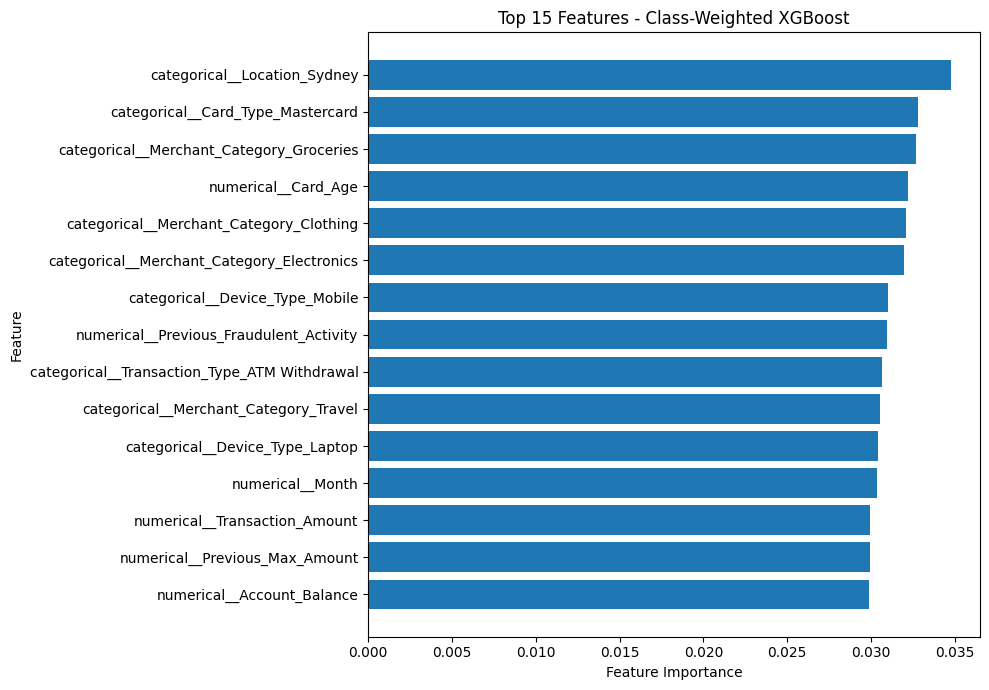

In [65]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features - Class-Weighted XGBoost")
plt.tight_layout()

plt.show()

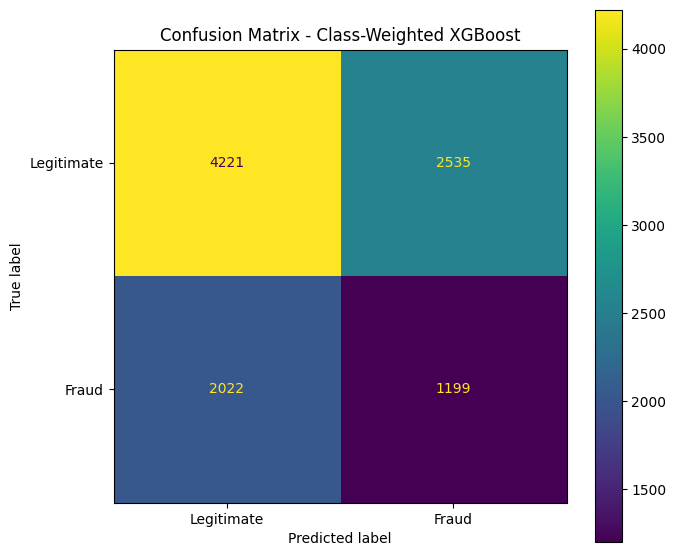

In [66]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test_behavior, final_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax)

ax.set_title("Confusion Matrix - Class-Weighted XGBoost")
plt.tight_layout()
plt.show()

In [67]:
import joblib
import os

# Create models folder if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save final trained model
joblib.dump(
    final_xgb_model,
    "models/final_fraud_detection_model.pkl"
)

print("Final fraud detection model saved successfully.")
print("Location: models/final_fraud_detection_model.pkl")

Final fraud detection model saved successfully.
Location: models/final_fraud_detection_model.pkl
